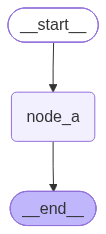

{'__interrupt__': [Interrupt(value='请输入您的姓名', id='64ff4b11869fd28acfa74f327c532e15')]}

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	node_a(node_a)
	__end__([<p>__end__</p>]):::last
	__start__ --> node_a;
	node_a --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [ ]:
from typing import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver
from rich import print as rprint

#1. 声明状态
class OverAllState(TypedDict):
    username:str

#2. 声明节点
def node_a(state:OverAllState)->OverAllState:
    # interrupt function
    username = interrupt("请输入您的姓名")
    return {
        "username":username
    }

#3. 构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a",node_a)
builder.add_edge(START,"node_a")
builder.add_edge("node_a",END)

#4. 想要使用中断 => 必须配置检查点
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

from IPython.display import display
display(graph)

config = {"configurable":{"thread_id":"123"}}
interrupt_res = graph.invoke({},config=config)
rprint(interrupt_res)

raw_mermaid = graph.get_graph().draw_mermaid()
print(raw_mermaid)


In [4]:
prompt = interrupt_res['__interrupt__'][0].value
rprint(prompt)
username = input(prompt)

# 5. 恢复图的中断执行
resume_res = graph.invoke(Command(resume=username),config=config)
rprint(resume_res)

请输入您的姓名

{'username': '小明'}